In [36]:
import pandas as pd
import numpy as np

In [46]:
matches = pd.read_csv("cricket_dataset.csv")
deliveries = pd.read_csv("deliveries.csv")

In [68]:
deliveries

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN


batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


<Axes: title={'center': 'IPL Top 10 Run Scorers'}, xlabel='batter'>

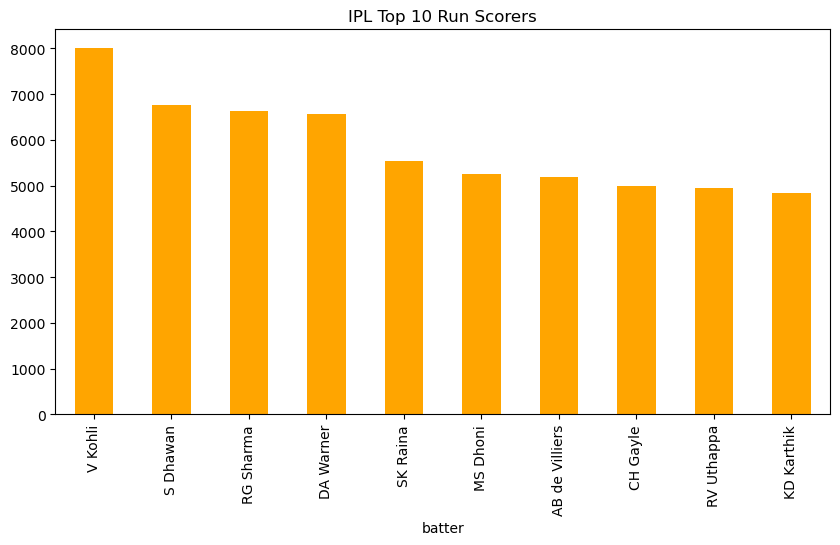

In [50]:
top_10 = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
print(top_10)
top_10.plot(kind="bar", color="orange", figsize=(10,5), title="IPL Top 10 Run Scorers")

season
2007/08    16809
2009       15376
2009/10    17754
2011       19928
2012       21323
2013       21487
2014       17943
2015       17427
2016       17962
2017       17920
2018       19098
2019       18607
2020/21    18566
2021       17727
2022       23052
2023       24428
2024       24657
Name: batsman_runs, dtype: int64


<Axes: title={'center': 'Total Runs Per IPL Season'}, xlabel='season'>

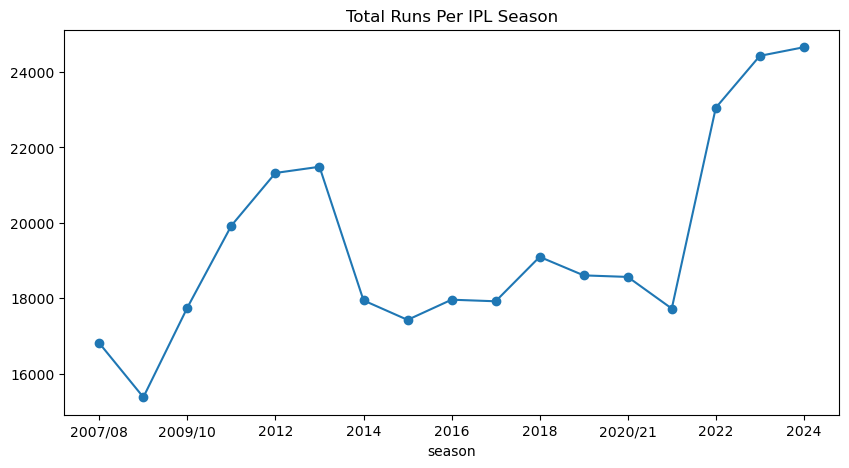

In [54]:
df = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_runs = df.groupby('season')['batsman_runs'].sum().sort_index()
print(season_runs)
season_runs.plot(kind='line', marker='o', title='Total Runs Per IPL Season', figsize=(10,5))

In [55]:
matches

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


In [57]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_impact = matches["toss_win_match_win"].mean() * 100
print(f"Toss winner team won {toss_impact:.2f}% times")

Toss winner team won 50.59% times


venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Wankhede Stadium, Mumbai                                              346.377778
Name: match_total_runs, dtype: float64


<Axes: title={'center': 'Top 10 Highest Scoring Venues'}, ylabel='venue'>

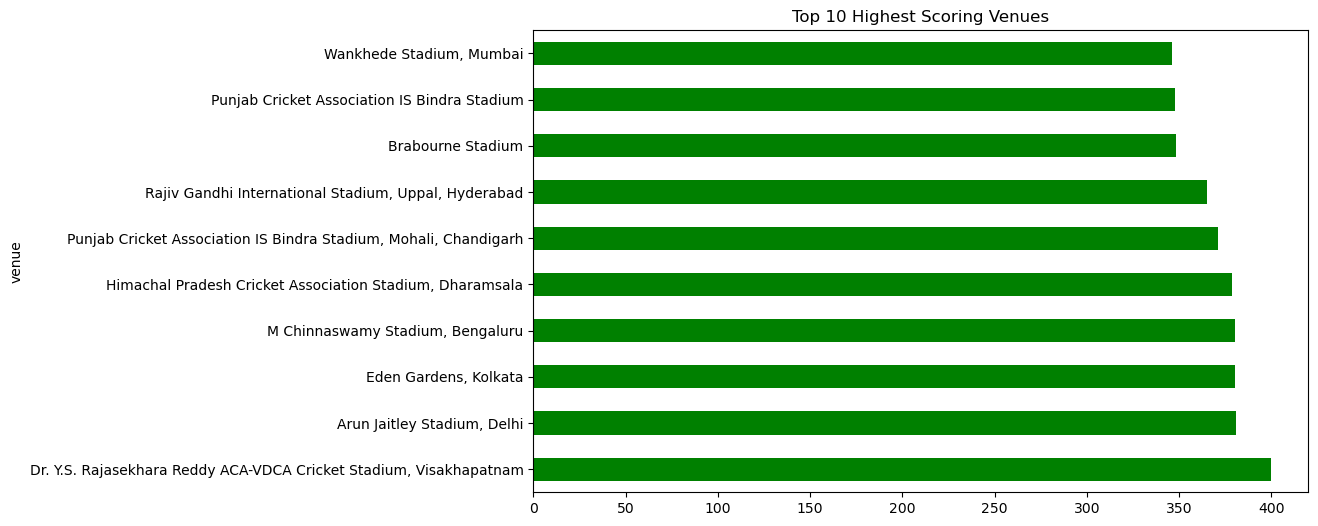

In [64]:
match_scores = deliveries.groupby("match_id")["total_runs"].sum().reset_index()
match_scores.rename(columns={"total_runs":"match_total_runs"}, inplace=True)
venue_scores = match_scores.merge(matches[["id","venue"]], left_on="match_id", right_on="id")
avg_venue_score = venue_scores.groupby("venue")["match_total_runs"].mean().sort_values(ascending=False)
print(avg_venue_score.head(10))
avg_venue_score.head(10).plot(kind="barh", figsize=(10,6), color="green", title="Top 10 Highest Scoring Venues")

Rising Pune Supergiant         62.50
Gujarat Titans                 62.22
Chennai Super Kings            57.98
Mumbai Indians                 55.17
Lucknow Super Giants           54.55
Delhi Capitals                 52.75
Kolkata Knight Riders          52.19
Rajasthan Royals               50.68
Sunrisers Hyderabad            48.35
Royal Challengers Bangalore    48.33
Royal Challengers Bengaluru    46.67
Kings XI Punjab                46.32
Gujarat Lions                  43.33
Kochi Tuskers Kerala           42.86
Punjab Kings                   42.86
Delhi Daredevils               41.61
Deccan Chargers                38.67
Rising Pune Supergiants        35.71
Pune Warriors                  26.09
Name: count, dtype: float64


<Axes: title={'center': 'Team Win % in IPL'}>

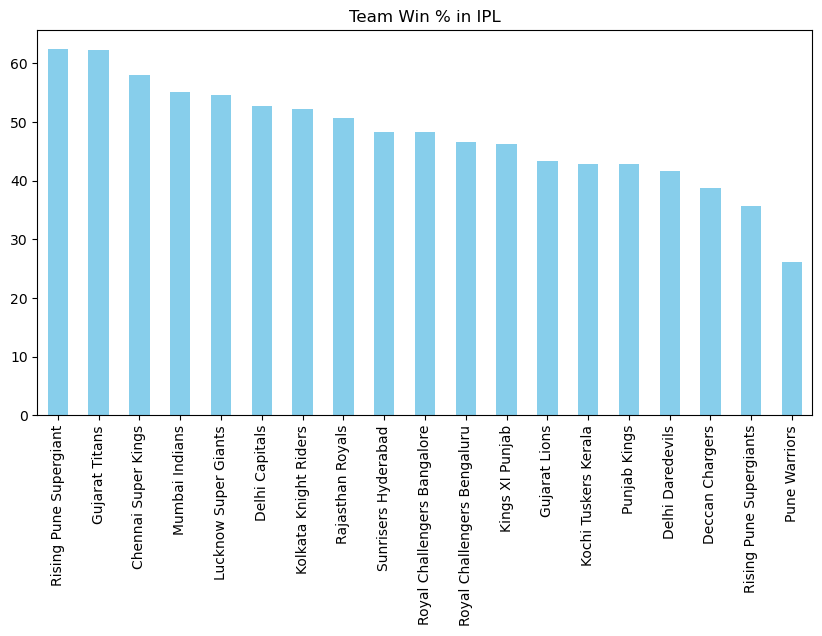

In [66]:
total_matches = matches["team1"].value_counts() + matches["team2"].value_counts()
total_wins = matches["winner"].value_counts()
win_rate = (total_wins / total_matches * 100).sort_values(ascending=False)
print(win_rate.round(2))
win_rate.plot(kind="bar", color="skyblue", figsize=(10,5), title="Team Win % in IPL")

                 total_runs  total_balls  strike_rate
batter                                               
AD Russell             2488         1515   164.224422
H Klaasen               993          613   161.990212
SP Narine              1534          984   155.894309
N Pooran               1769         1143   154.768154
LS Livingstone          939          609   154.187192
GJ Maxwell             2772         1842   150.488599
RM Patidar              799          534   149.625468
Abhishek Sharma        1377          925   148.864865
V Sehwag               2728         1833   148.827059
AB de Villiers         5181         3487   148.580442


<Axes: title={'center': 'Top 10 Strike Rates | Min 500 Balls'}, xlabel='batter'>

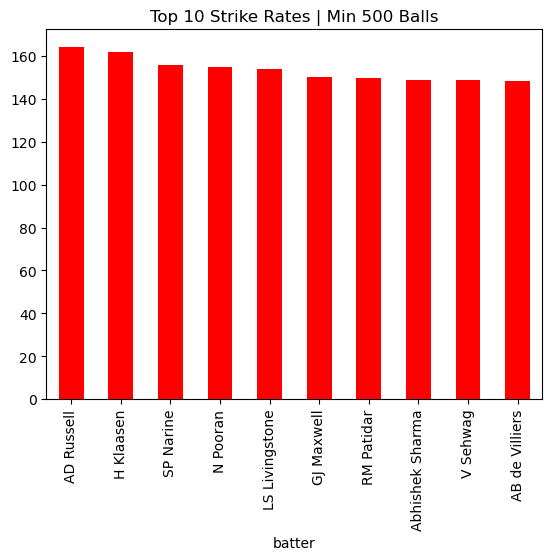

In [67]:
batsman_stats = deliveries.groupby("batter").agg(
    total_runs=("batsman_runs","sum"),
    total_balls=("ball","count")
)
batsman_stats["strike_rate"] = (batsman_stats["total_runs"] / batsman_stats["total_balls"]) * 100
sr_500 = batsman_stats[batsman_stats["total_balls"] >= 500].sort_values("strike_rate", ascending=False)
print(sr_500.head(10))
sr_500["strike_rate"].head(10).plot(kind="bar", color="red", title="Top 10 Strike Rates | Min 500 Balls")